# 01. Data Cleaning & Text Processing Pipeline

Notebook này được sử dụng để chạy trực quan quy trình ETL (Extract, Transform, Load) đã được định nghĩa trong `src/pipeline.py` và kiểm tra chất lượng dữ liệu đầu ra (`master data`).

**Mục tiêu:**
1. Kích hoạt pipeline xử lý dữ liệu thô.
2. Trực quan hóa một số dòng dữ liệu đầu ra để kiểm tra.
3. Kiểm tra các giá trị thiếu (missing values) và thống kê cơ bản.


In [12]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập thư mục gốc của project để có thể import các module từ src/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Cấu hình hiển thị pandas để dễ xem dữ liệu
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

print(f"Thư mục gốc: {project_root}")

Thư mục gốc: d:\PROJECT\digital_marketing_analysis


## 1. Chạy Pipeline Xử lý dữ liệu
Gọi trực tiếp file `pipeline.py` thông qua lệnh hệ thống để đảm bảo luồng chạy trơn tru.

In [13]:
!py ../src/pipeline.py

[*] Thư mục gốc dự án: d:\PROJECT\digital_marketing_analysis

BƯỚC 1: XỬ LÝ DỮ LIỆU CATALOG SẢN PHẨM
[+] Đang làm sạch dữ liệu catalog từ: d:\PROJECT\digital_marketing_analysis\data\raw\raw_website_catalog
[+] Đã xử lý và lưu 5063 sản phẩm vào: d:\PROJECT\digital_marketing_analysis\data\master\master_catalog_products.csv

BƯỚC 2: XỬ LÝ DỮ LIỆU BÀI VIẾT FACEBOOK
[+] Đang làm sạch dữ liệu Facebook từ: d:\PROJECT\digital_marketing_analysis\data\raw\raw_facebook_posts
[+] Đã xử lý và lưu 2671 bài viết vào: d:\PROJECT\digital_marketing_analysis\data\master\master_facebook_posts.csv

BƯỚC 3: XỬ LÝ DỮ LIỆU GOOGLE REVIEWS (Làm sạch + Trích xuất khía cạnh)
[+] Đang làm sạch dữ liệu Google Reviews từ: d:\PROJECT\digital_marketing_analysis\data\raw\raw_google_reviews
[+] Đã làm sạch 1830 đánh giá.
[+] Đang xử lý văn bản (tiền xử lý + trích xuất khía cạnh từ khóa)...
[TextProcessing] Bắt đầu xử lý văn bản cho 1830 reviews...
[TextProcessing] Hoàn tất xử lý văn bản cho 1830 reviews.
  - Thái độ phụ

## 2. Kiểm tra chất lượng dữ liệu Catalog Sản phẩm
Đọc file `master_catalog_products.csv` vừa tạo và kiểm tra.

In [14]:
catalog_path = os.path.join(project_root, 'data', 'master', 'master_catalog_products.csv')
if os.path.exists(catalog_path):
    df_catalog = pd.read_csv(catalog_path)
    display(df_catalog.head())
    
    print("\n--- THÔNG TIN DỮ LIỆU ---")
    df_catalog.info()
    
    print("\n--- KIỂM TRA DỮ LIỆU THIẾU (NULL) ---")
    print(df_catalog.isnull().sum())
else:
    print("Chưa có dữ liệu Catalog trong data/master/")

,brand,product_name,sku,category_l1,category_l2,regular_price_vnd,sale_price_vnd,discount_rate,availability,product_url,image_url,description
0,Hoa Sen Home,Mũi khoan SDS PLUS-5X 8x100x160,F03000168,Thiết bị cầm tay,Phụ kiện,54432.0,54432.0,0.0,True,https://hoasenhome.vn/product/mui-khoan-sds-plus-5x-8x100x160,https://cdn.hoasenhome.vn/catalog/product/c/2/c27000016_karndfjbjvwdje8j.jpg,Mũi khoan SDS PLUS-5X Đầu mũi khoan 4 lưỡi cắt giúp ngăn mũi không bị mắc kẹt trong bê tông cốt ...
1,Hoa Sen Home,Mũi khoan SDS PLUS-5X 6x100x160,F03000167,Thiết bị cầm tay,Phụ kiện,49248.0,49248.0,0.0,True,https://hoasenhome.vn/product/mui-khoan-sds-plus-5x-6x100x160,https://cdn.hoasenhome.vn/catalog/product/c/2/c27000015_vwhio2s6x2vsccqx.jpg,Mũi khoan SDS PLUS-5X Đầu mũi khoan 4 lưỡi cắt giúp ngăn mũi không bị mắc kẹt trong bê tông cốt ...
2,Hoa Sen Home,Mũi khoan SDS PLUS-5X 6x50x110,F03000175,Thiết bị cầm tay,Phụ kiện,45360.0,45360.0,0.0,True,https://hoasenhome.vn/product/mui-khoan-sds-plus-5x-6x50x110,https://cdn.hoasenhome.vn/catalog/product/c/2/c27000014_ltw40s7lspgsroqk.jpg,Mũi khoan SDS PLUS-5X Đầu mũi khoan 4 lưỡi cắt giúp ngăn mũi không bị mắc kẹt trong bê tông cốt ...
3,Hoa Sen Home,Mũi khoan tường Concrete 10x80x120,F03000173,Thiết bị cầm tay,Phụ kiện,33912.0,33912.0,0.0,True,https://hoasenhome.vn/product/mui-khoan-tuong-concrete-10x80x120,https://cdn.hoasenhome.vn/catalog/product/c/2/c27000008_qa18jzcy8kh6ee88.jpg,Mũi Khoan Tường Bosch chuyên dùng cho các máy khoan động lực để khoan tường gạch và tường bê tôn...
4,Hoa Sen Home,Mũi khoan tường Concrete 8x80x120,F03000176,Thiết bị cầm tay,Phụ kiện,27756.0,27756.0,0.0,True,https://hoasenhome.vn/product/mui-khoan-tuong-concrete-8x80x120,https://cdn.hoasenhome.vn/catalog/product/c/2/c27000007_g3ic6ejjypdoobpn.jpg,- Loại mũi khoan này có khả năng khoan các loại vật cứng như gạch và bê tông. Đây là loại mũi kh...



--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 5063 entries, 0 to 5062
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              5063 non-null   str    
 1   product_name       5063 non-null   str    
 2   sku                4991 non-null   str    
 3   category_l1        5063 non-null   str    
 4   category_l2        5063 non-null   str    
 5   regular_price_vnd  5063 non-null   float64
 6   sale_price_vnd     5063 non-null   float64
 7   discount_rate      5063 non-null   float64
 8   availability       5063 non-null   bool   
 9   product_url        5063 non-null   str    
 10  image_url          5057 non-null   str    
 11  description        4969 non-null   str    
dtypes: bool(1), float64(3), str(8)
memory usage: 440.2 KB

--- KIỂM TRA DỮ LIỆU THIẾU (NULL) ---
brand                 0
product_name          0
sku                  72
category_l1           0
category_l2

## 3. Kiểm tra chất lượng dữ liệu Bài viết Facebook
Đọc file `master_facebook_posts.csv`.

In [15]:
fb_path = os.path.join(project_root, 'data', 'master', 'master_facebook_posts.csv')
if os.path.exists(fb_path):
    df_fb = pd.read_csv(fb_path)
    display(df_fb.head())
    
    print("\n--- PHÂN BỐ TƯƠNG TÁC THEO THƯƠNG HIỆU ---")
    # Thống kê tổng tương tác trung bình mỗi bài viết
    display(df_fb.groupby('brand')['total_engagement'].describe())
else:
    print("Chưa có dữ liệu Facebook trong data/master/")

,brand,post_id,url,post_time,text,is_video,likes,comments,shares,views_count,total_engagement,react_like,react_love,react_haha,react_wow,react_sad,react_angry,react_care,positive_reacts,negative_reacts
0,Hoa Sen Home,1.222873e+17,https://www.facebook.com/reel/2355433224945188/,2026-05-23 12:01:38,⚡MÁY SIẾT BULONG LUSFIX – TIẾT KIỆM THỜI GIAN GẤP 5 LẦN SO VỚI DỤNG CỤ TRUYỀN THỐNG\n\nNếu bạn đ...,True,2,0,0,39,2,2,0,0,0,0,0,0,0,0
1,Hoa Sen Home,1.222873e+17,https://www.facebook.com/reel/1309941971101737/,2026-05-23 12:01:26,LƯƠNG VỀ TING TING - SĂN DEAL LINH ĐÌNH\n Chỉ có tại Megalive ngày 24.05 - 25.05 từ 18.00 - 23.0...,True,3,0,0,45,3,2,1,0,0,0,0,0,1,0
2,Hoa Sen Home,1.222873e+17,https://www.facebook.com/hoasenhome.online/posts/pfbid0AUt4Qtz33AEbaR6troc2NZTUs8CJFzvEyE3gtw7xt...,2026-05-23 05:00:14,LƯƠNG VỀ TING TING - SĂN DEAL LINH ĐÌNH\n Chỉ có tại Megalive ngày 24.05 - 25.05 từ 18.00 - 23.0...,False,2,0,0,0,2,2,0,0,0,0,0,0,0,0
3,Hoa Sen Home,1.222872e+17,https://www.facebook.com/hoasenhome.online/posts/pfbid031D2jLa6KoDfTJG9mGWzjaK1QS4BYDMeivpPboAVH...,2026-05-22 13:00:06,CHỌN LUSHINE D002 – ĐẦU TƯ DÀI HẠN BỀN BỈ CHO CĂN BẾP CỦA BẠN\n\nCăn bếp vừa là nơi chuẩn bị nhữ...,False,4,2,1,0,7,4,0,0,0,0,0,0,0,0
4,Hoa Sen Home,1.222872e+17,https://www.facebook.com/hoasenhome.online/posts/pfbid02BnfvcKsTtvXJfh9DE4TqtmF4nfKM2Jb1sqAZXEEi...,2026-05-22 12:30:03,HOA SEN HOME – ĐỒNG HÀNH CÙNG GIA ĐÌNH VIỆT XÂY DỰNG TỔ ẤM\n\nMỗi ngôi nhà đều được dựng xây từ ...,False,4,2,1,0,7,4,0,0,0,0,0,0,0,0



--- PHÂN BỐ TƯƠNG TÁC THEO THƯƠNG HIỆU ---


,count,mean,std,min,25%,50%,75%,max
brand,,,,,,,,
Hoa Sen Home,994.0,30.391348,148.056482,0.0,4.0,7.0,13.00,3358.0
Rita Võ,999.0,28.212212,93.883840,0.0,8.0,12.0,17.00,1567.0
Viglacera,678.0,211.148968,851.015673,0.0,24.0,39.0,72.75,10981.0


## 4. Kiểm tra chất lượng dữ liệu Google Reviews
Đọc file `master_google_reviews.csv` và kiểm tra dữ liệu đã được làm sạch + trích xuất khía cạnh.

,brand,rating,review_text,cleaned_review_text
0,Hoa Sen Home,5,"Thuộc hệ thống bán lẻ của tập đoàn Hoa Sen, Hoa Sen Home có Show room đẹp, nhân viên tư vấn nhiệ...","thuộc hệ thống bán lẻ của tập đoàn hoa sen, hoa sen home có show room đẹp, nhân viên tư vấn nhiệ..."
1,Hoa Sen Home,5,To rộng rãi. Dể bán vật liệu xây dựng,to rộng rãi. dể bán vật liệu xây dựng
2,Hoa Sen Home,5,"Dịch vụ tốt, giao hàng nhanh ! Tuy nhiễn giá cao.","dịch vụ tốt, giao hàng nhanh ! tuy nhiễn giá cao."
3,Hoa Sen Home,5,"Hàng đa dạng, tư vấn nhiệt tình","hàng đa dạng, tư vấn nhiệt tình"
4,Hoa Sen Home,4,"Showroom Hoa Sen Home có bán đầy đủ và gần như toàn bộ về VLXD và nội thất, có gạch ngói, thiết ...","showroom hoa sen home có bán đầy đủ và gần như toàn bộ về vlxd và nội thất, có gạch ngói, thiết ..."
5,Hoa Sen Home,5,"Hoa Sen Home đa dạng vật liệu xây dựng, từ tôn, sắt thép đến đồ nội thất cơ bản đều có. Không gi...","hoa sen home đa dạng vật liệu xây dựng, từ tôn, sắt thép đến đồ nội thất cơ bản đều có. không gi..."
6,Hoa Sen Home,5,NaN,NaN
7,Hoa Sen Home,5,NaN,NaN
8,Hoa Sen Home,5,NaN,NaN
9,Hoa Sen Home,4,NaN,NaN



--- TỔNG QUAN DỮ LIỆU ---
Tổng số review: 1830
Reviews có nội dung chữ: 1155
Reviews chỉ có số sao (không có chữ): 675

--- PHÂN BỐ SỐ SAO THEO THƯƠNG HIỆU ---


rating,1,2,3,4,5
brand,,,,,
Hoa Sen Home,27,7,28,57,321
Rita Võ,29,5,17,33,914
Viglacera,22,12,39,50,269


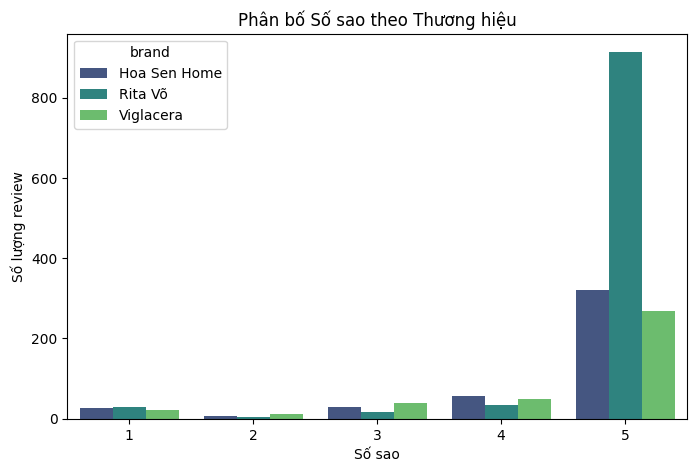


--- KIỂM TRA PHÂN TÍCH KHÍA CẠNH (ASPECT) ---


,Số lượng nhắc đến
aspect_product,719
aspect_service,541
aspect_showroom,421
aspect_price,116
aspect_delivery,34



--- KIỂM TRA DỮ LIỆU THIẾU (NULL) ---
brand                    0
place_name               0
user_name                0
rating                   0
review_text            672
review_date              0
review_date_raw          0
cleaned_review_text    675
aspect_service           0
aspect_price             0
aspect_product           0
aspect_showroom          0
aspect_delivery          0
dtype: int64


In [16]:
review_path = os.path.join(project_root, 'data', 'master', 'master_google_reviews.csv')
if os.path.exists(review_path):
    df_review = pd.read_csv(review_path)
    display(df_review[['brand', 'rating', 'review_text', 'cleaned_review_text']].head(10))
    
    print(f"\n--- TỔNG QUAN DỮ LIỆU ---")
    print(f"Tổng số review: {len(df_review)}")
    print(f"Reviews có nội dung chữ: {df_review['cleaned_review_text'].notna().sum()}")
    print(f"Reviews chỉ có số sao (không có chữ): {df_review['cleaned_review_text'].isna().sum()}")
    
    print("\n--- PHÂN BỐ SỐ SAO THEO THƯƠNG HIỆU ---")
    display(df_review.groupby('brand')['rating'].value_counts().unstack(fill_value=0))
    
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_review, x='rating', hue='brand', palette='viridis')
    plt.title('Phân bố Số sao theo Thương hiệu')
    plt.xlabel('Số sao')
    plt.ylabel('Số lượng review')
    plt.show()
    
    print("\n--- KIỂM TRA PHÂN TÍCH KHÍA CẠNH (ASPECT) ---")
    aspect_cols = [c for c in df_review.columns if c.startswith('aspect_')]
    aspect_summary = df_review[aspect_cols].sum().sort_values(ascending=False)
    display(pd.DataFrame(aspect_summary, columns=['Số lượng nhắc đến']))
    
    print("\n--- KIỂM TRA DỮ LIỆU THIẾU (NULL) ---")
    print(df_review.isnull().sum())
else:
    print("Chưa có dữ liệu Review trong data/master/")

### 4.1. Điều tra sự chênh lệch giá trị Null (review_text vs cleaned_review_text)

Số lượng giá trị null của `review_text` (672) và `cleaned_review_text` (675) chênh lệch nhau 3 dòng. Điều này xảy ra có thể do 3 đánh giá ban đầu có nội dung chữ gốc (không null), nhưng nội dung đó chỉ chứa các emoji, ký tự biểu tượng hoặc ký hiệu đặc biệt (ví dụ: ⭐, 💯, 😁, ...) mà hàm làm sạch `clean_text_for_nlp` sẽ lọc bỏ hoàn toàn. 

Sau khi lọc bỏ toàn bộ các ký tự đó, văn bản trở thành chuỗi rỗng `""`. Khi lưu xuống file CSV và được thư viện pandas đọc lại, các chuỗi rỗng này sẽ mặc định được hiểu là giá trị `NaN` (Null).

Ta tiến hành kiểm tra:

In [17]:
if os.path.exists(review_path):
    # Lọc các dòng có review_text gốc KHÔNG null nhưng cleaned_review_text LẠI null
    df_discrepancy = df_review[df_review['review_text'].notna() & df_review['cleaned_review_text'].isna()]
    print(f"Số lượng review bị chuyển thành rỗng sau khi làm sạch: {len(df_discrepancy)}")
    display(df_discrepancy[['brand', 'rating', 'review_text', 'cleaned_review_text']])
else:
    print("Chưa có dữ liệu Review để kiểm tra.")

Số lượng review bị chuyển thành rỗng sau khi làm sạch: 3


,brand,rating,review_text,cleaned_review_text
318,Hoa Sen Home,5,😁 …,NaN
699,Rita Võ,5,⭐️⭐️⭐️⭐️⭐️,NaN
1146,Rita Võ,5,💯💯💯 …,NaN
